In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(csv):
    df = pd.read_csv(csv)

    props = ['poisson', 'young', 'volume_frac']
    comparisons = {
        "req_sim": ("requested", "real"),
        "req_pred": ("requested", "predicted"),
        "pred_sim": ("predicted", "real")
    }
    metric_fns = {
        "mse": mean_squared_error,
        "mae": mean_absolute_error,
        "r2": r2_score
    }

    metrics = {}

    for prop in props:
        metrics[prop] = {}

        for comp_name, (a, b) in comparisons.items():
            y1 = df[f"{prop}_{a}"]
            y2 = df[f"{prop}_{b}"]

            # Compute all metrics for this comparison
            metrics[prop][comp_name] = {
                m: fn(y1, y2) for m, fn in metric_fns.items()
            }

        # ---- PRINTING BLOCK ----
        print(f"\n### {prop.upper()} ###")

        for comp_name in comparisons.keys():
            mse = metrics[prop][comp_name]["mse"]
            mae = metrics[prop][comp_name]["mae"]
            r2  = metrics[prop][comp_name]["r2"]

            c = comp_name.replace("_", " vs ")

            print(f"MSE ({c}): {mse:.6f}")
            print(f"MAE ({c}): {mae:.6f}")
            print(f"R²  ({c}): {r2:.6f}")

    return metrics


In [2]:
csv = 'inverse_exp_results2.csv'
m1 = calculate_metrics(csv)


### POISSON ###
MSE (req vs sim): 0.011884
MAE (req vs sim): 0.070484
R²  (req vs sim): 0.920520
MSE (req vs pred): 0.006724
MAE (req vs pred): 0.057079
R²  (req vs pred): 0.955029
MSE (pred vs sim): 0.011187
MAE (pred vs sim): 0.066912
R²  (pred vs sim): 0.908374

### YOUNG ###
MSE (req vs sim): 0.039622
MAE (req vs sim): 0.111157
R²  (req vs sim): 0.874027
MSE (req vs pred): 0.010349
MAE (req vs pred): 0.073716
R²  (req vs pred): 0.967098
MSE (pred vs sim): 0.041350
MAE (pred vs sim): 0.123991
R²  (pred vs sim): 0.836467

### VOLUME_FRAC ###
MSE (req vs sim): 0.000143
MAE (req vs sim): 0.007850
R²  (req vs sim): 0.958056
MSE (req vs pred): 0.000061
MAE (req vs pred): 0.005908
R²  (req vs pred): 0.982118
MSE (pred vs sim): 0.000242
MAE (pred vs sim): 0.009843
R²  (pred vs sim): 0.919112


In [3]:
csv_old = 'inverse_model_old_results.csv'
m2 = calculate_metrics(csv_old)


### POISSON ###
MSE (req vs sim): 0.028376
MAE (req vs sim): 0.140458
R²  (req vs sim): 0.810225
MSE (req vs pred): 0.002640
MAE (req vs pred): 0.031892
R²  (req vs pred): 0.982345
MSE (pred vs sim): 0.022137
MAE (pred vs sim): 0.120687
R²  (pred vs sim): 0.835493

### YOUNG ###
MSE (req vs sim): 0.035021
MAE (req vs sim): 0.149838
R²  (req vs sim): 0.888654
MSE (req vs pred): 0.014502
MAE (req vs pred): 0.076340
R²  (req vs pred): 0.953893
MSE (pred vs sim): 0.059221
MAE (pred vs sim): 0.208187
R²  (pred vs sim): 0.739918

### VOLUME_FRAC ###
MSE (req vs sim): 0.000995
MAE (req vs sim): 0.026637
R²  (req vs sim): 0.708288
MSE (req vs pred): 0.000205
MAE (req vs pred): 0.007558
R²  (req vs pred): 0.939958
MSE (pred vs sim): 0.000608
MAE (pred vs sim): 0.021365
R²  (pred vs sim): 0.781281


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_single_metric_grouped(m1, m2, metric="mse", comparisons = None, model_names=("Model 1", "Model 2")):
    props = ["poisson", "young", "volume_frac"]
    if not comparisons:
        comparisons = ["req_sim", "req_pred", "pred_sim"]

    labels = []
    model1_vals = []
    model2_vals = []

    for prop in props:
        for comp in comparisons:
            labels.append(f"{prop}\n{comp}")
            model1_vals.append(m1[prop][comp][metric])
            model2_vals.append(m2[prop][comp][metric])

        # Add spacing
        labels.append("")
        model1_vals.append(np.nan)
        model2_vals.append(np.nan)

    x = np.arange(len(labels))
    width = 0.5

    plt.figure(figsize=(15, 6))

    bars1 = plt.bar(x - width/2, model1_vals, width, label=model_names[0], color="steelblue")
    bars2 = plt.bar(x + width/2, model2_vals, width, label=model_names[1], color="orange")

    # -----------------------------
    # Add value labels on top of bars
    # -----------------------------
    def add_labels(bars, vals):
        for bar, val in zip(bars, vals):
            if not np.isnan(val):  # only label real bars
                height = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width()/2,
                    height,
                    f"{val:.3f}",
                    ha='center', va='bottom',
                    fontsize=8
                )

    add_labels(bars1, model1_vals)
    add_labels(bars2, model2_vals)

    # Formatting
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylabel(metric.upper())
    plt.title(f"Comparison of {metric.upper()} Between Models")
    plt.legend()
    plt.grid(axis='y', linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


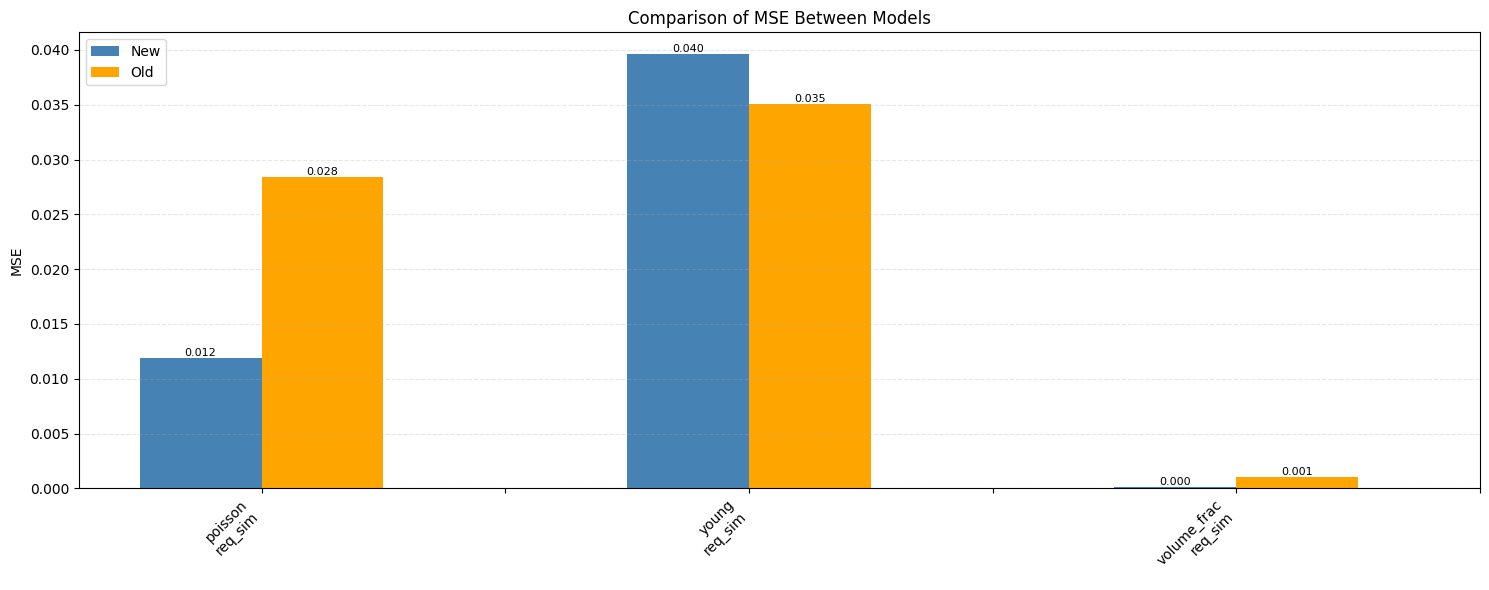

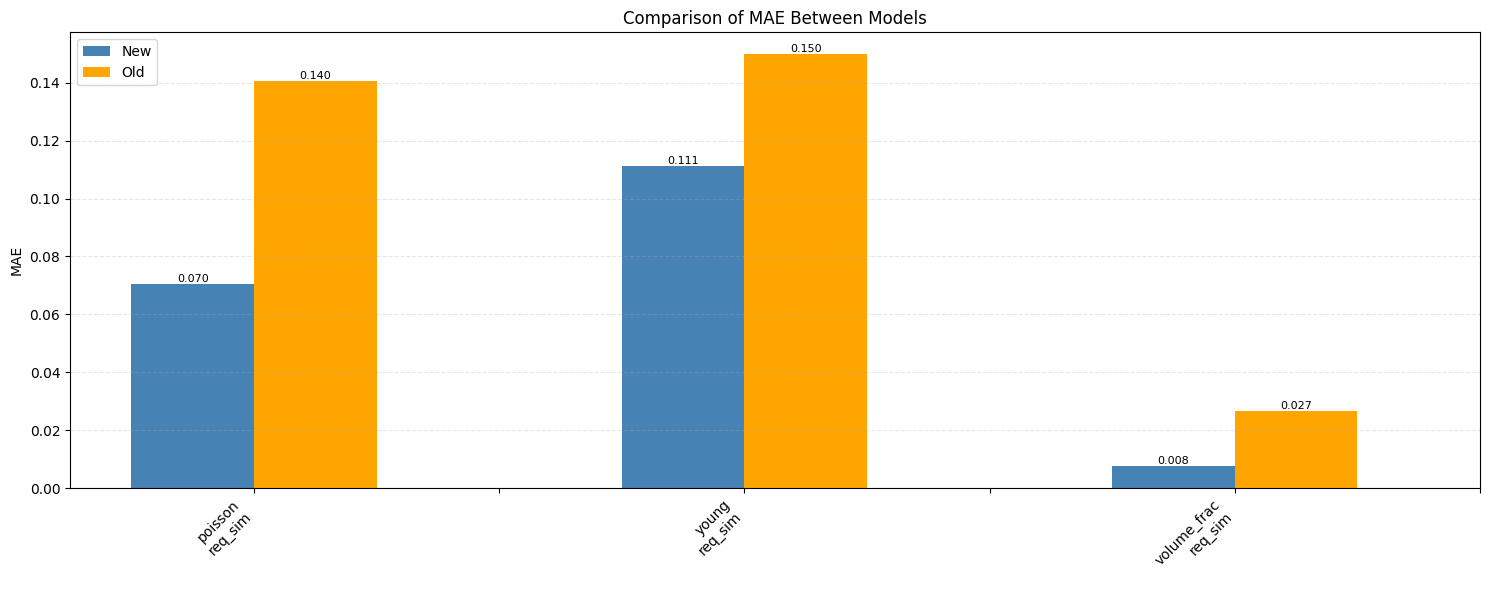

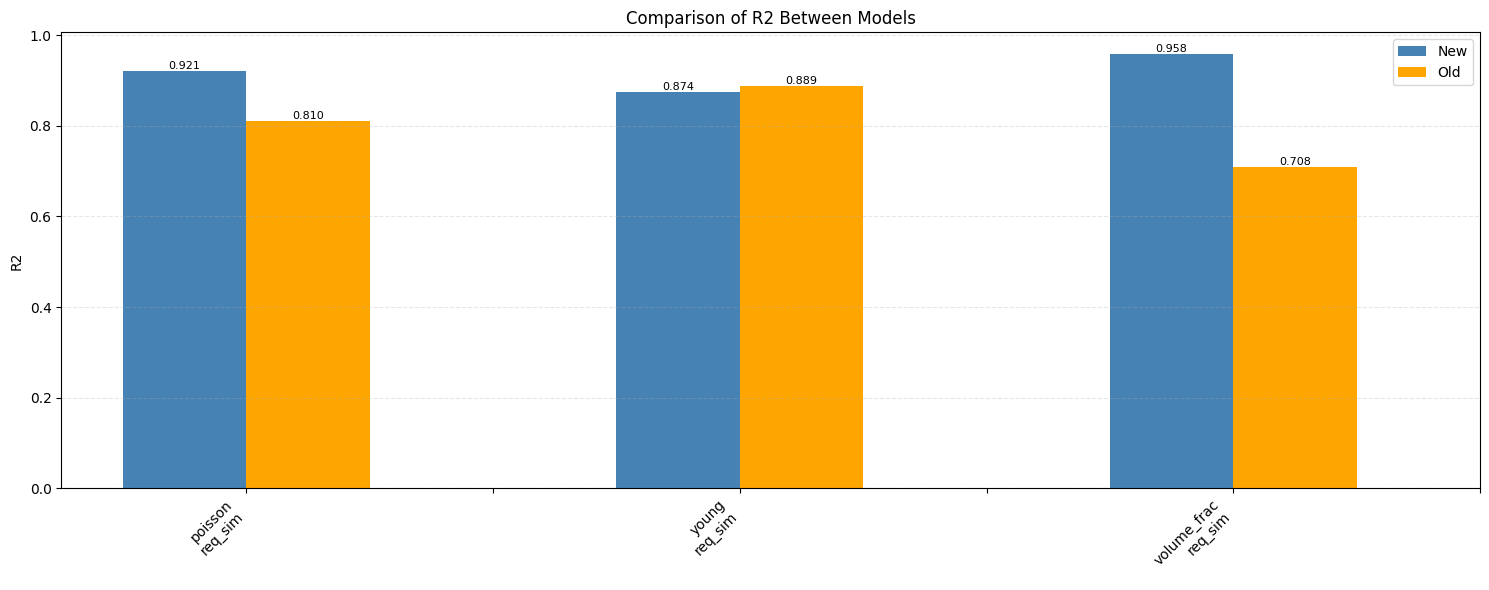

In [ ]:
metrics = ['mse', 'mae', 'r2']
for metric in metrics:
    plot_single_metric_grouped(m1, m2, metric=metric, comparisons=['pred_sim'], model_names=['System B', 'System A'])